In [1]:
# Setup + load 306 Nav2/Gazebo trials from data/ (scalar CSV + t,x,y traj).
%matplotlib inline
import os, sys, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle
from scipy import stats
from IPython.display import display

# data/ : world_layout.py (geometry), optimal_paths.json (A* paths), 306 per-trial CSV.
DATA = os.path.abspath('data')
sys.path.insert(0, DATA)
import world_layout as wl   # goal / spawn / obstacles

PLANNERS   = ['DWA', 'RPP', 'MPPI']
FAULTS     = ['sensor_bias', 'sensor_drift', 'sensor_noise', 'actuator_degradation']
SEVERITIES = [0.0, 0.25, 0.5, 0.75, 1.0]
FAULT_ON   = [0.25, 0.5, 0.75, 1.0]
GOAL       = wl.GOAL
ALPHA      = 0.05
COLORS     = {'DWA': 'blue', 'RPP': 'red', 'MPPI': 'green'}
ROBOT_RADIUS = 0.22 

# l_i = feasible optimal path (A*), for SPL
with open(os.path.join(DATA, 'optimal_paths.json')) as f:
    OPTIMAL = {p['index']: p['optimal'] for p in json.load(f)['paths']}

# metrics derived from trajectory
def trajectory_metrics(traj, goal, success, v_stop=0.03):
    x, y, t = traj['x'].values, traj['y'].values, traj['t'].values
    dg = np.hypot(x - goal[0], y - goal[1])
    step, dt = np.hypot(np.diff(x), np.diff(y)), np.diff(t)
    speed = step / dt
    t_stop, T_trial = float(dt[speed < v_stop].sum()), float(dt.sum())
    return dict(final_dist_to_goal=float(dg[-1]), stopped_time_ratio=t_stop / T_trial, time_to_goal=float(t[-1] - t[0]) if success == 1 else np.nan, x_final=float(x[-1]), y_final=float(y[-1]))


def load_batch(sub):
    d = os.path.join(DATA, sub)
    recs = []
    for f in sorted(x for x in os.listdir(d) if x.endswith('.csv')):
        r = pd.read_csv(os.path.join(d, f)).iloc[0].to_dict()
        r.update(trajectory_metrics(pd.read_csv(os.path.join(d, 'traj', f)), GOAL, r['success']))
        recs.append(r)
    return pd.DataFrame(recs)

df = pd.concat([load_batch(s) for s in ['baseline', 'sensor_bias', 'sensor_drift', 'sensor_noise', 'actuator']], ignore_index=True)

# SPL = S_i * l_i / max(p_i, l_i) ; failure -> S_i = 0 -> SPL = 0
df['optimal'] = df['spawn_index'].map(OPTIMAL)
p, ell, s = (df['path_length'].values, df['optimal'].values, df['success'].values.astype(float))
df['spl'] = np.where(s > 0, s * ell / np.maximum(p, ell), 0.0)

# fault-on trials
fon = df[df.severity > 0]


/usr/local/lib/python3.12/dist-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
print('overall success rate (306 trials):', round(df.success.mean(), 3))
print('\npooled robustness (success rate, fault-on trials):')
print(fon.groupby('planner')['success'].mean().reindex(PLANNERS).round(3).to_string())
print('\nsuccess rate per planner x fault:')
display(fon.pivot_table('success', 'planner', 'fault_type', aggfunc='mean').round(3))

overall success rate (306 trials): 0.833

pooled robustness (success rate, fault-on trials):
planner
DWA     0.896
RPP     0.812
MPPI    0.760

success rate per planner x fault:


fault_type,actuator_degradation,sensor_bias,sensor_drift,sensor_noise
planner,,,,
DWA,0.875,1.0,0.917,0.792
MPPI,0.417,1.0,0.917,0.708
RPP,0.583,1.0,0.917,0.750


In [3]:
# holm correction
def holm(pvals):
    p = np.asarray(pvals, float)
    order, adj, run = np.argsort(p), np.empty(p.size), 0.0
    for rank, i in enumerate(order):
        run = max(run, (p.size - rank) * p[i])
        adj[i] = min(run, 1.0)
    return adj

# Kruskal-Wallis on 5 severity levels (s=0 = shared 'none' baseline)
def kruskal_dose(metric, faults):
    rows = []
    for pl in PLANNERS:
        base = df[(df.fault_type == 'none') & (df.planner == pl)][metric].values
        for ft in faults:
            groups = [base] + [df[(df.planner == pl) & (df.fault_type == ft) & (df.severity == sv)][metric].values for sv in FAULT_ON]
            N = sum(g.size for g in groups)
            H, pv = stats.kruskal(*groups)
            rows.append(dict(planner=pl, fault=ft, metric=metric, N=N, H=H, p=pv, eps2=H / (N - 1)))
    out = pd.DataFrame(rows)
    out['p_holm'] = holm(out['p'].values)
    out['significant'] = out['p_holm'] < ALPHA
    return out

# axis: min-clearance
SAFETY   = ['sensor_bias', 'sensor_drift']
# axis: R_stop
LIVENESS = ['sensor_noise', 'actuator_degradation']     

h1 = pd.concat([kruskal_dose('min_clearance', SAFETY), kruskal_dose('stopped_time_ratio', LIVENESS)], ignore_index=True)

h1_spl = kruskal_dose('spl', FAULTS)

print('significant (Holm-corrected)  -  primary:', int(h1.significant.sum()), '/', len(h1), ' |  SPL:', int(h1_spl.significant.sum()), '/', len(h1_spl))
display(h1.round({'H': 2, 'p': 5, 'eps2': 3, 'p_holm': 5}))
display(h1_spl.round({'H': 2, 'p': 5, 'eps2': 3, 'p_holm': 5}))

significant (Holm-corrected)  -  primary: 12 / 12  |  SPL: 12 / 12


,planner,fault,metric,N,H,p,eps2,p_holm,significant
0,DWA,sensor_bias,min_clearance,30,23.72,0.00009,0.818,0.00018,True
1,DWA,sensor_drift,min_clearance,30,22.44,0.00016,0.774,0.00018,True
2,RPP,sensor_bias,min_clearance,30,27.87,0.00001,0.961,0.00008,True
3,RPP,sensor_drift,min_clearance,30,26.85,0.00002,0.926,0.00008,True
4,MPPI,sensor_bias,min_clearance,30,27.72,0.00001,0.956,0.00008,True
5,MPPI,sensor_drift,min_clearance,30,27.10,0.00002,0.934,0.00008,True
6,DWA,sensor_noise,stopped_time_ratio,30,16.71,0.00220,0.576,0.00439,True
7,DWA,actuator_degradation,stopped_time_ratio,30,13.99,0.00732,0.482,0.00732,True
8,RPP,sensor_noise,stopped_time_ratio,30,20.18,0.00046,0.696,0.00230,True
9,RPP,actuator_degradation,stopped_time_ratio,30,18.20,0.00113,0.628,0.00339,True


,planner,fault,metric,N,H,p,eps2,p_holm,significant
0,DWA,sensor_bias,spl,30,28.42,0.00001,0.980,0.00012,True
1,DWA,sensor_drift,spl,30,14.97,0.00476,0.516,0.01528,True
2,DWA,sensor_noise,spl,30,24.66,0.00006,0.850,0.00059,True
3,DWA,actuator_degradation,spl,30,15.33,0.00406,0.529,0.01528,True
4,RPP,sensor_bias,spl,30,28.42,0.00001,0.980,0.00012,True
5,RPP,sensor_drift,spl,30,15.47,0.00382,0.533,0.01528,True
6,RPP,sensor_noise,spl,30,22.51,0.00016,0.776,0.00111,True
7,RPP,actuator_degradation,spl,30,21.28,0.00028,0.734,0.00139,True
8,MPPI,sensor_bias,spl,30,23.70,0.00009,0.817,0.00082,True
9,MPPI,sensor_drift,spl,30,15.13,0.00445,0.522,0.01528,True


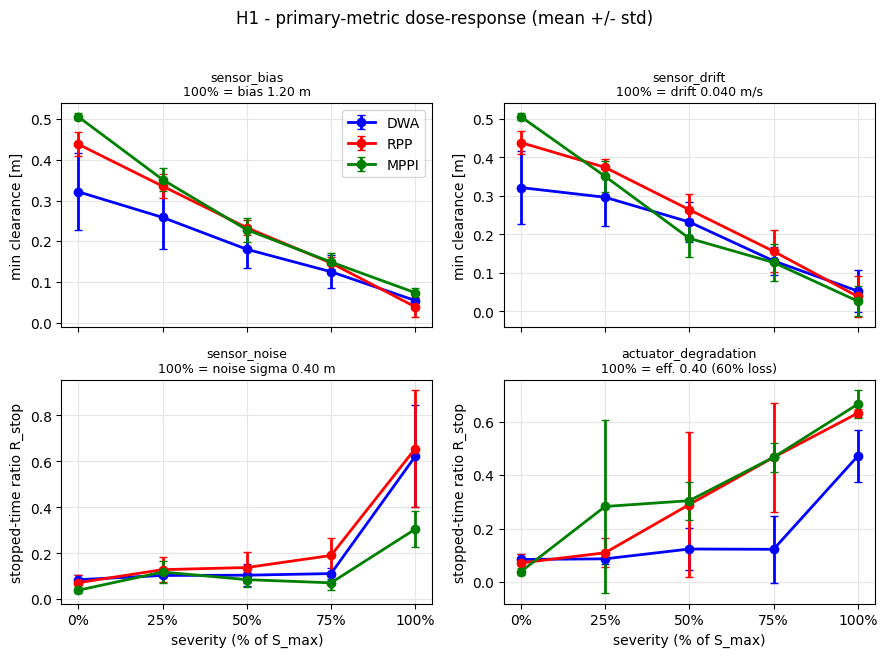

In [4]:
PCT_LABELS = ['0%', '25%', '50%', '75%', '100%']
FAULT_SMAX = {'sensor_bias': '100% = bias 1.20 m',
              'sensor_drift': '100% = drift 0.040 m/s',
              'sensor_noise': '100% = noise sigma 0.40 m',
              'actuator_degradation': '100% = eff. 0.40 (60% loss)'}

def dose_fig(specs, suptitle, sharey=False, ylim=None, clip=None):
    fig, axes = plt.subplots(2, 2, figsize=(9, 6.4), sharex=True, sharey=sharey)
    for ax, (ft, metric, ylabel) in zip(axes.flat, specs):
        base = df[df.fault_type == 'none'].assign(fault_type=ft)
        sub = pd.concat([base, df[df.fault_type == ft]], ignore_index=True)
        for pl in PLANNERS:
            g = sub[sub.planner == pl].groupby('severity')[metric]
            mu, sd = g.mean(), g.std()
            yerr = np.vstack([mu - np.clip(mu - sd, *clip), np.clip(mu + sd, *clip) - mu]) if clip else sd.values
            ax.errorbar(mu.index, mu.values, yerr=yerr, marker='o', capsize=3, lw=2, color=COLORS[pl], label=pl)
        ax.set_title(f'{ft}\n{FAULT_SMAX[ft]}', fontsize=9)
        ax.set_xticks(SEVERITIES)
        ax.set_ylabel(ylabel)
        ax.grid(True, color='0.9')
        if ylim:
            ax.set_ylim(*ylim)
    for ax in axes[1]:
        ax.set_xlabel('severity (% of S_max)')
        ax.set_xticklabels(PCT_LABELS)
    axes[0, 0].legend()
    fig.suptitle(suptitle, y=1.02)
    fig.tight_layout()
    return fig

fig_h1_primary = dose_fig([('sensor_bias', 'min_clearance', 'min clearance [m]'),
          ('sensor_drift', 'min_clearance', 'min clearance [m]'),
          ('sensor_noise', 'stopped_time_ratio', 'stopped-time ratio R_stop'),
          ('actuator_degradation', 'stopped_time_ratio', 'stopped-time ratio R_stop')],
          'H1 - primary-metric dose-response (mean +/- std)')
plt.show()

In [5]:
# non-parametric effect size, A vs B
def cliffs_delta(a, b):
    a, b = np.asarray(a, float), np.asarray(b, float)
    d = a[:, None] - b[None, :]
    return float((np.sum(d > 0) - np.sum(d < 0)) / (a.size * b.size))

# Wilcoxon signed-rank on 24 paired diffs by (severity, spawn)
def wilcoxon_planners(metric, faults):
    pairs = [('DWA', 'RPP'), ('DWA', 'MPPI'), ('RPP', 'MPPI')]
    out = []
    for ft in faults:
        rows = []
        for A, B in pairs:
            def series(pl):
                m = (df.planner == pl) & (df.fault_type == ft) & df.severity.isin(FAULT_ON)
                return df.loc[m].set_index(['severity', 'spawn_index'])[metric]
            j = pd.concat([series(A).rename('a'), series(B).rename('b')], axis=1)
            a, b = j.a.values, j.b.values
            d = a - b
            with warnings.catch_warnings():   # zeros in diffs -> normal approximation
                warnings.filterwarnings('ignore', message='Exact p-value.*')
                warnings.filterwarnings('ignore', message='Sample size too small.*')
                W, pv = stats.wilcoxon(a, b, zero_method='wilcox', alternative='two-sided')
            rows.append(dict(fault=ft, metric=metric, A=A, B=B, n=d.size, median_diff=float(np.median(d)), cliffs=cliffs_delta(a, b), W=W, p=pv))
        r = pd.DataFrame(rows)
        r['p_holm'] = holm(r['p'].values)
        r['significant'] = r['p_holm'] < ALPHA
        out.append(r)
    return pd.concat(out, ignore_index=True)

# OUTCOME (descriptive): success / SPL / collisions per (fault x planner), pooled fault-on.
outcome = (fon.groupby(['fault_type', 'planner']).agg(success=('success', 'mean'), spl=('spl', 'mean'), collisions=('collisions', 'sum')).round(3))

display(outcome)

# paired Wilcoxon n=24 on SPL
h2 = wilcoxon_planners('spl', FAULTS)
print('significant (Holm-corrected):', int(h2.significant.sum()), '/', len(h2))
display(h2.round({'median_diff': 4, 'cliffs': 3, 'p': 4, 'p_holm': 4}))

success    spl  collisions
fault_type           planner                            
actuator_degradation DWA        0.875  0.764           0
                     MPPI       0.417  0.330           0
                     RPP        0.583  0.525           0
sensor_bias          DWA        1.000  0.995           0
                     MPPI       1.000  0.988           0
                     RPP        1.000  0.996           0
sensor_drift         DWA        0.917  0.899           2
                     MPPI       0.917  0.885           2
                     RPP        0.917  0.903           2
sensor_noise         DWA        0.792  0.661           0
                     MPPI       0.708  0.532           0
                     RPP        0.750  0.637           0

significant (Holm-corrected): 10 / 12


,fault,metric,A,B,n,median_diff,cliffs,W,p,p_holm,significant
0,sensor_bias,spl,DWA,RPP,24,0.0000,-0.038,6.0,0.3454,0.3454,False
1,sensor_bias,spl,DWA,MPPI,24,0.0067,0.330,0.0,0.0010,0.0029,True
2,sensor_bias,spl,RPP,MPPI,24,0.0048,0.344,0.0,0.0010,0.0029,True
3,sensor_drift,spl,DWA,RPP,24,-0.0029,-0.156,22.0,0.0057,0.0057,True
4,sensor_drift,spl,DWA,MPPI,24,0.0127,0.424,0.0,0.0000,0.0001,True
5,sensor_drift,spl,RPP,MPPI,24,0.0183,0.524,0.0,0.0000,0.0001,True
6,sensor_noise,spl,DWA,RPP,24,-0.0092,-0.069,82.0,0.6009,0.6009,False
7,sensor_noise,spl,DWA,MPPI,24,0.0536,0.519,4.0,0.0003,0.0006,True
8,sensor_noise,spl,RPP,MPPI,24,0.0675,0.486,0.0,0.0002,0.0006,True
9,actuator_degradation,spl,DWA,RPP,24,0.0060,0.174,47.0,0.0173,0.0173,True


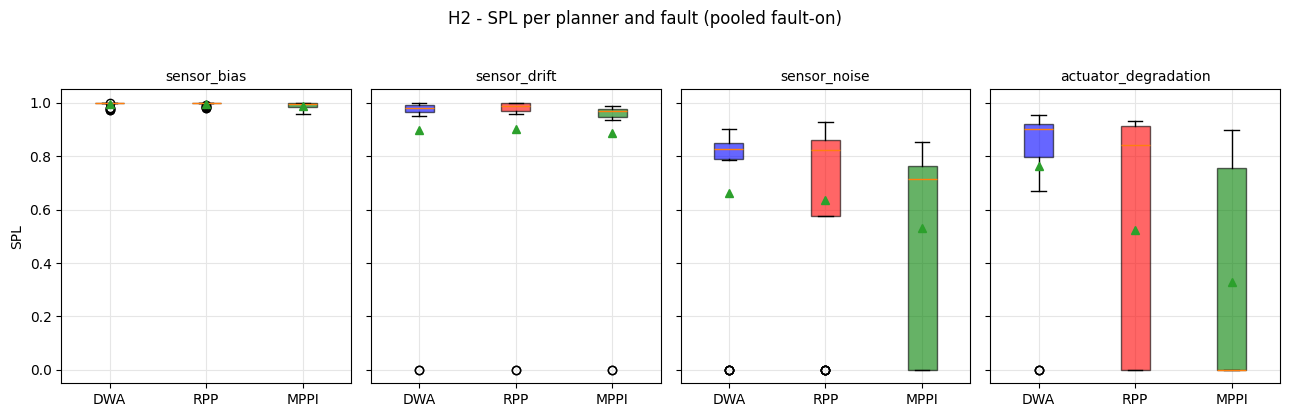

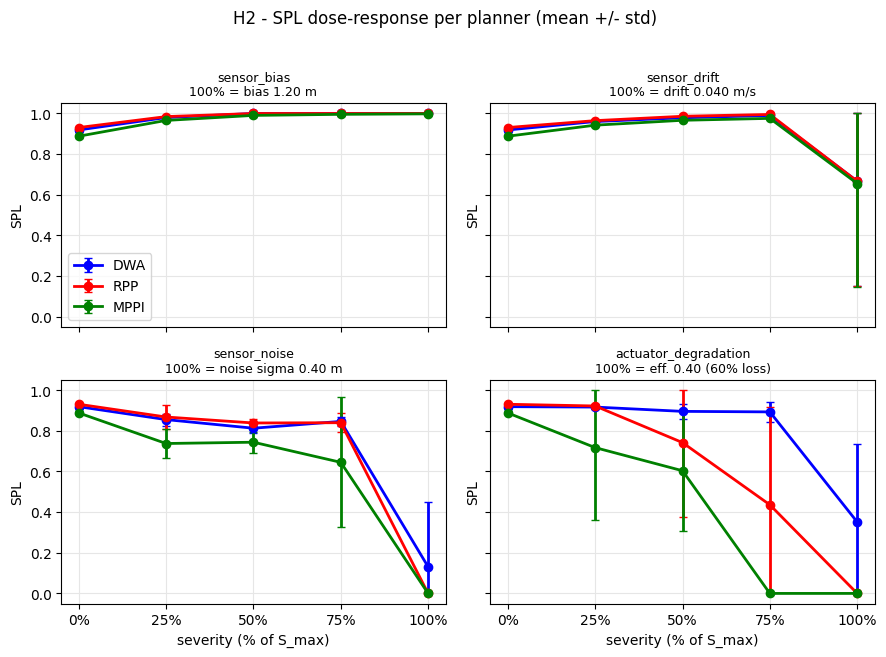

In [6]:
# SPL distribution per planner in each fault, pooled over fault-on levels
fig_h2, axes = plt.subplots(1, 4, figsize=(13, 4), sharey=True)
for ax, ft in zip(axes, FAULTS):
    data = [fon[(fon.fault_type == ft) & (fon.planner == pl)]['spl'].values for pl in PLANNERS]
    bp = ax.boxplot(data, patch_artist=True, showmeans=True)
    for box, pl in zip(bp['boxes'], PLANNERS):
        box.set(facecolor=COLORS[pl], alpha=0.6)
    ax.set_xticklabels(PLANNERS)
    ax.set_title(ft, fontsize=10)
    ax.grid(True, color='0.9')
axes[0].set_ylabel('SPL')
fig_h2.suptitle('H2 - SPL per planner and fault (pooled fault-on)', y=1.03)
fig_h2.tight_layout()
plt.show()

# SPL dose-response by severity (mean)
fig_h2_dose_spl = dose_fig([(ft, 'spl', 'SPL') for ft in FAULTS], 'H2 - SPL dose-response per planner (mean +/- std)', sharey=True, ylim=(-0.05, 1.05), clip=(0, 1))
plt.show()

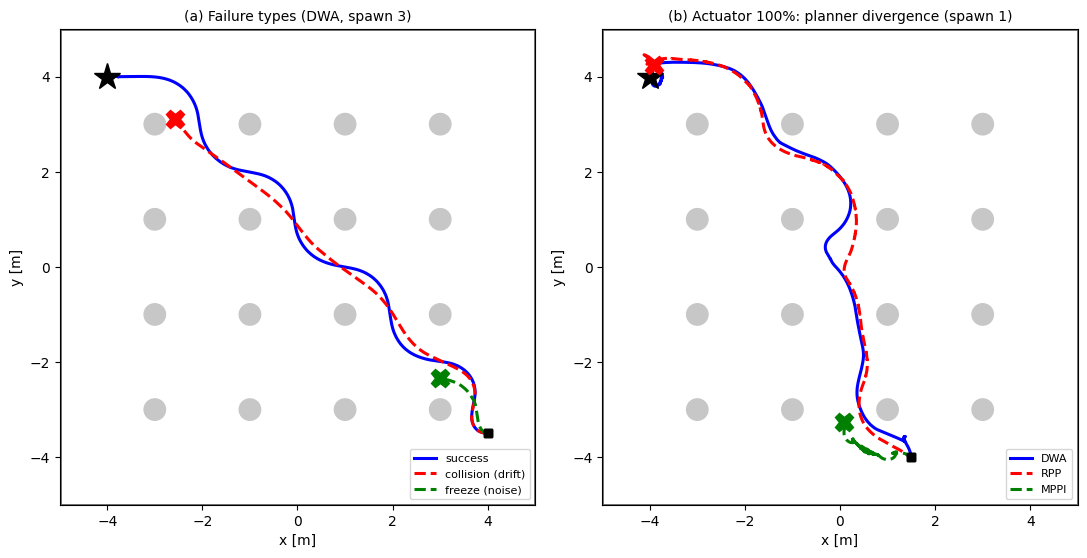

In [7]:
# (a) failure TYPES (fixed planner DWA, spawn 3): success / collision (drift) / freeze (noise)
# (b) actuator sev1.0, 3 planners same spawn 1: DWA reaches, RPP entraps on goal, MPPI freeze
def draw_arena(ax):
    e = wl.MAP_HALF_EXTENT
    ax.add_patch(Rectangle((-e, -e), 2 * e, 2 * e, fill=False, ec='0.4', lw=2))
    for ox, oy in wl.OBSTACLES:
        ax.add_patch(Circle((ox, oy), wl.OBSTACLE_RADIUS, color='0.78'))
    ax.plot(*GOAL, marker='*', color='k', markersize=20, zorder=5)   # goal
    ax.set_aspect('equal')
    ax.set_xlim(-e, e)
    ax.set_ylim(-e, e)
    ax.set_xlabel('x [m]')
    ax.set_ylabel('y [m]')

def plot_traj(ax, sub, name, color, label, success):
    tr = pd.read_csv(os.path.join(DATA, sub, 'traj', name))
    ax.plot(tr.x, tr.y, color=color, ls='-' if success else '--', lw=2.2, label=label, zorder=4)
    ax.plot(tr.x.iloc[0], tr.y.iloc[0], marker='s', color='k', markersize=6, zorder=6)   # spawn
    if not success:
        ax.plot(tr.x.iloc[-1], tr.y.iloc[-1], marker='X', color=color, markersize=13, zorder=6)  # final pose

fig_traj, (axa, axb) = plt.subplots(1, 2, figsize=(11, 5.4))

# (a) failure types on a fixed planner
draw_arena(axa)
for sub, name, col, lab, ok in [
        ('baseline', 'DWA_baseline_sp3.csv', 'blue', 'success', 1),
        ('sensor_drift', 'DWA_sensor_drift_sev1.0_sp3.csv', 'red', 'collision (drift)', 0),
        ('sensor_noise', 'DWA_sensor_noise_sev1.0_sp3.csv', 'green', 'freeze (noise)', 0)]:
    plot_traj(axa, sub, name, col, lab, ok)
axa.set_title('(a) Failure types (DWA, spawn 3)', fontsize=10)
axa.legend(loc='lower right', fontsize=8)

# (b) actuator 100%: planner divergence, colored by planner (COLORS)
draw_arena(axb)
for pl in PLANNERS:
    name = f'{pl}_actuator_degradation_sev1.0_sp1.csv'
    r = pd.read_csv(os.path.join(DATA, 'actuator', name)).iloc[0]
    plot_traj(axb, 'actuator', name, COLORS[pl], pl, int(r['success']))
axb.set_title('(b) Actuator 100%: planner divergence (spawn 1)', fontsize=10)
axb.legend(loc='lower right', fontsize=8)

fig_traj.tight_layout()
plt.show()

In [8]:
# relevant data
top = fon[fon.severity == 1.0]

# collisions: nearest obstacle to the final pose + footprint gap from the perimeter walls
col = df[df.collisions > 0].copy()
obs = np.array(wl.OBSTACLES)
col['nearest_obstacle'] = [tuple(obs[np.argmin(np.hypot(obs[:, 0] - x, obs[:, 1] - y))]) for x, y in zip(col.x_final, col.y_final)]
col['wall_gap'] = wl.MAP_HALF_EXTENT - wl.WALL_THICKNESS - np.maximum(col.x_final.abs(), col.y_final.abs()) - ROBOT_RADIUS
display(col[['planner', 'fault_type', 'severity', 'spawn_index', 'nearest_obstacle', 'wall_gap']].round(2))

print('bias 100% - mean min clearance [m]:', round(top[top.fault_type == 'sensor_bias'].min_clearance.mean(), 3))
print('noise 100% - max path length [m]:', round(top[top.fault_type == 'sensor_noise'].path_length.max(), 2))
print('actuator 100% - MPPI mean final distance to goal [m]:', round(top[(top.fault_type == 'actuator_degradation') & (top.planner == 'MPPI')].final_dist_to_goal.mean(), 2))


,planner,fault_type,severity,spawn_index,nearest_obstacle,wall_gap
110,DWA,sensor_drift,1.0,2,"(-3.0, 3.0)",1.35
111,DWA,sensor_drift,1.0,3,"(-3.0, 3.0)",1.46
134,MPPI,sensor_drift,1.0,2,"(-3.0, 3.0)",1.45
135,MPPI,sensor_drift,1.0,3,"(-3.0, 3.0)",1.49
158,RPP,sensor_drift,1.0,2,"(-3.0, 3.0)",1.61
159,RPP,sensor_drift,1.0,3,"(-3.0, 3.0)",1.44


bias 100% - mean min clearance [m]: 0.055
noise 100% - max path length [m]: 15.05
actuator 100% - MPPI mean final distance to goal [m]: 8.03


In [9]:
# Summary table
def agg_cell(g):
    ok = g[g.success == 1]
    return pd.Series({
        'n': len(g),
        'success_rate': g.success.mean(),
        'spl_mean': g.spl.mean(),
        'clearance_mean': g.min_clearance.mean(),
        'clearance_min': g.min_clearance.min(),
        'collisions_total': int(g.collisions.sum()),
        'time_mean': ok.time_to_goal.mean() if len(ok) else np.nan,
        'time_std': ok.time_to_goal.std(ddof=1) if len(ok) > 1 else np.nan,
        'recovery_mean': g.n_recovery.mean(),
        'dist_goal_mean': g.final_dist_to_goal.mean(), 
        'dist_goal_median': g.final_dist_to_goal.median(),
    })

summary = (df.groupby(['planner', 'fault_type', 'severity']).apply(agg_cell, include_groups=False).reset_index().round(3))

display(summary)

,planner,fault_type,severity,n,success_rate,spl_mean,clearance_mean,clearance_min,collisions_total,time_mean,time_std,recovery_mean,dist_goal_mean,dist_goal_median
0,DWA,actuator_degradation,0.25,6.0,1.000,0.917,0.317,0.250,0.0,53.074,4.164,0.000,0.224,0.225
1,DWA,actuator_degradation,0.50,6.0,1.000,0.896,0.277,0.171,0.0,65.762,11.116,1.000,0.208,0.216
2,DWA,actuator_degradation,0.75,6.0,1.000,0.893,0.188,0.028,0.0,78.442,19.525,1.333,0.222,0.234
3,DWA,actuator_degradation,1.00,6.0,0.500,0.352,0.027,0.005,0.0,191.339,30.999,14.167,0.764,0.252
4,DWA,none,0.00,6.0,1.000,0.919,0.322,0.225,0.0,48.776,3.906,0.000,0.218,0.218
5,DWA,sensor_bias,0.25,6.0,1.000,0.980,0.259,0.192,0.0,45.673,3.353,0.000,0.209,0.213
6,DWA,sensor_bias,0.50,6.0,1.000,1.000,0.180,0.134,0.0,44.141,3.620,0.000,0.214,0.216
7,DWA,sensor_bias,0.75,6.0,1.000,1.000,0.125,0.077,0.0,43.578,3.703,0.000,0.213,0.214
8,DWA,sensor_bias,1.00,6.0,1.000,1.000,0.054,0.016,0.0,43.207,3.778,0.000,0.212,0.212
9,DWA,sensor_drift,0.25,6.0,1.000,0.960,0.296,0.223,0.0,46.664,3.398,0.000,0.219,0.220


In [10]:
# Export figures
FIG_DIR = 'figures'
os.makedirs(FIG_DIR, exist_ok=True)
for name, fig in [('h1_dose_primaria',fig_h1_primary), 
                  ('h2_dose_spl', fig_h2_dose_spl), 
                  ('h2_profili', fig_h2),
                  ('traiettorie_failure_mode', fig_traj)]:
    fig.savefig(os.path.join(FIG_DIR, name + '.png'), dpi=300, bbox_inches='tight')